In [1]:
import sys, os
# --- project bootstrap ---------------------------------------------------
# This notebook lives under notebooks/<pre|post>_training/, but it imports the
# my_image_jepa modules (dataset, model, eval, losses, lars, scheduler) and
# reads paths relative to the my_image_jepa root (./data, ./checkpoints, cfgs/).
# Walk up to that root (the dir holding main.py + cfgs/) and make it both the
# working directory and an import root, so the notebook runs from anywhere.
from pathlib import Path

ROOT = Path.cwd()
while not ((ROOT / "main.py").exists() and (ROOT / "cfgs").is_dir()) and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"project root: {ROOT}")

project root: /Users/hawardizayee/Desktop/AMI/eb_jepa/examples/my_image_jepa


# Findings 

-  global vmax = 13.73 (largest single activation across the whole train set)
-  global dmax = 7.60 (largest |view 1 − view 2| difference)

In [2]:
artifact_dir = '/Users/hawardizayee/Desktop/AMI/eb_jepa/examples/my_image_jepa/artifacts/image_jepa_checkpoint:v0'

import torch
ckpt = torch.load(f"{artifact_dir}/latest.pth.tar", map_location="cpu")

In [3]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


from dataset import get_train_transforms

base_train_dataset = CIFAR10(
        root= "./data", train=True, download=False, 
    )

In [4]:
from dataset import ImageDataset

train_transform = get_train_transforms()
train_dataset = ImageDataset(base_train_dataset,train_transform,2)
train_loader = DataLoader(train_dataset,batch_size=2,shuffle=False)

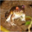

In [5]:
base_train_dataset[0][0]

In [6]:
batch = next(iter(train_loader))
(view1,view2),label = batch

print(view1.shape,view2.shape)


torch.Size([2, 3, 32, 32]) torch.Size([2, 3, 32, 32])


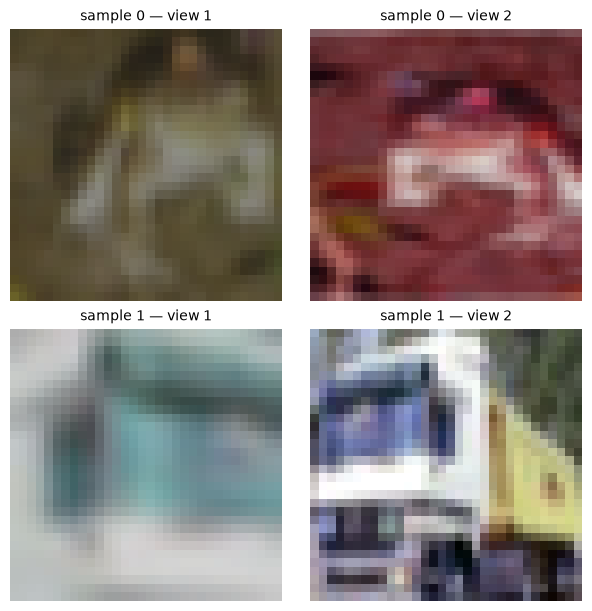

In [7]:
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

def denorm(img):
    return (img * std + mean).clamp(0, 1)   # back to [0, 1]

def show_views(view1, view2, max_images=4):
    """Gallery of both views: one row per sample, capped at max_images.

    view1, view2: [B, 3, H, W] batches of the two augmented views.
    """
    n = min(view1.shape[0], max_images)
    if view1.shape[0] > max_images:
        print(f"note: batch has {view1.shape[0]} samples, showing the first {max_images}")

    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n), constrained_layout=True, squeeze=False)

    for row in range(n):
        for col, view in enumerate([view1, view2]):
            ax = axes[row][col]
            ax.imshow(denorm(view[row]).permute(1, 2, 0).cpu().numpy())
            ax.set_title(f"sample {row} — view {col + 1}", fontsize=10)
            ax.axis("off")

    plt.show()

show_views(view1, view2)

In [8]:
from model import ResNet18, ImageSSL

backbone = ResNet18()

model = ImageSSL(
    backbone= backbone,
    features_dim= backbone.features_dim
)

model.load_state_dict(ckpt["model_state_dict"])


<All keys matched successfully>

In [9]:


model.eval()
with torch.no_grad():
    for batch in train_loader:
        (view0,view1),label = batch
        features_1, z1 = model(view0)
        features_2, z2 = model(view1)
        break


In [10]:
print(features_1.shape,z1.shape)
print(features_2.shape,z2.shape)

torch.Size([2, 512]) torch.Size([2, 2048])
torch.Size([2, 512]) torch.Size([2, 2048])


In [11]:
print(features_1.min(),features_1.max())
print(features_2.min(),features_2.max())


tensor(0.) tensor(1.9805)
tensor(0.) tensor(1.0664)


In [12]:
import numpy as np

# dataset-global color scales: p99 over the train set (both views).
# p99 (not max) so a handful of outlier neurons don't wash out the heatmap — see the
# distribution below: max ~13 but p99 ~0.9, so scaling to max wastes 90%+ of the range.
#   global_vmax  -> activation ceiling
#   global_dmax  -> |view1 - view2|  (across-VIEW difference)
#   global_sdmax -> |sample_i - sample_j| first view (across-SAMPLE difference)
scan_loader = DataLoader(train_dataset, batch_size=256, shuffle=False, num_workers=2)

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")

act_samples = []     # subsample of activations
diff_samples = []    # subsample of |view1 - view2|          (across-view)
sdiff_samples = []   # subsample of |sample_i - sample_j|    (across-sample, first view)

model.eval()
model.to(device)
with torch.no_grad():
    for i, ((v1, v2), _) in enumerate(scan_loader):
        feat1, _ = model(v1.to(device))
        feat2, _ = model(v2.to(device))
        # keep every 4th batch to bound memory; p99 is robust to subsampling
        if i % 4 == 0:
            act_samples.append(feat1.flatten().cpu())
            act_samples.append(feat2.flatten().cpu())
            diff_samples.append((feat1 - feat2).abs().flatten().cpu())
            # across-sample: each first-view feature minus the next sample's (roll by 1)
            sdiff_samples.append((feat1 - feat1.roll(1, 0)).abs().flatten().cpu())
model.to("cpu")   # back to cpu so the earlier cells keep working as-is

act_samples = torch.cat(act_samples).numpy()
diff_samples = torch.cat(diff_samples).numpy()
sdiff_samples = torch.cat(sdiff_samples).numpy()

global_vmax = np.quantile(act_samples, 0.99)
global_dmax = np.quantile(diff_samples, 0.99)
global_sdmax = np.quantile(sdiff_samples, 0.99)
# one shared ceiling for BOTH difference columns, so a color means the same magnitude
# whether it's an across-view or an across-sample difference. Use the larger of the two.
global_diffmax = max(global_dmax, global_sdmax)

print(f"global vmax  (p99 activation):      {global_vmax:.4f}   (max {act_samples.max():.4f})")
print(f"global dmax  (p99 across-view):     {global_dmax:.4f}   (max {diff_samples.max():.4f})")
print(f"global sdmax (p99 across-sample):   {global_sdmax:.4f}   (max {sdiff_samples.max():.4f})")
print(f"global diffmax (shared diff scale): {global_diffmax:.4f}")

device: mps
global vmax  (p99 activation):      0.9217   (max 12.0103)
global dmax  (p99 across-view):     0.3809   (max 6.4785)
global sdmax (p99 across-sample):   1.1399   (max 11.7756)
global diffmax (shared diff scale): 1.1399


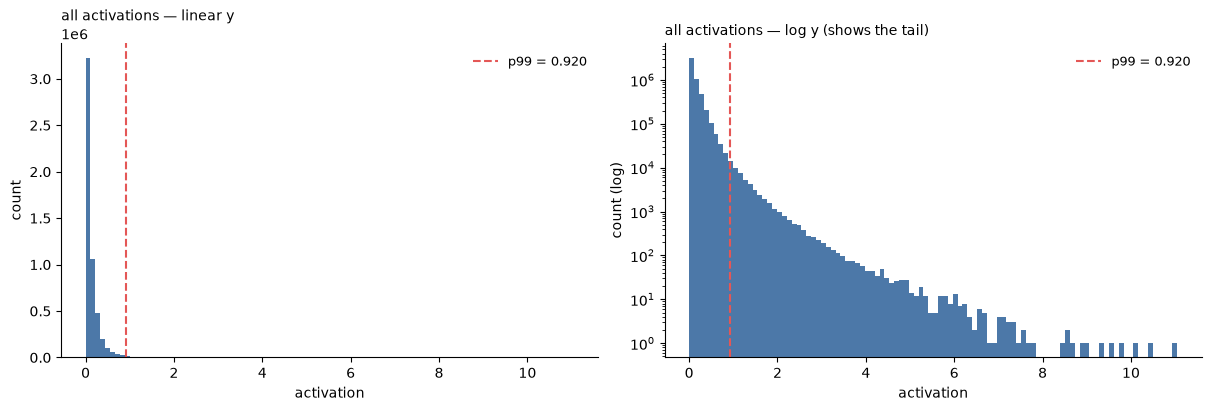

exact zeros: 32.4% of all values
mean: 0.1236, median: 0.0493
p99: 0.9203, max: 11.0475


In [13]:
import numpy as np

# distribution of neuron activations over a sample of the train set
n_batches = 20   # 20 batches x 256 images x 2 views x 512 neurons ~ 5.2M values

acts = []
model.eval()
model.to(device)
with torch.no_grad():
    for i, ((v1, v2), _) in enumerate(scan_loader):
        feat1, _ = model(v1.to(device))
        feat2, _ = model(v2.to(device))
        acts.append(feat1.flatten().cpu())
        acts.append(feat2.flatten().cpu())
        if i + 1 >= n_batches:
            break
model.to("cpu")

acts = torch.cat(acts).numpy()
p99 = np.quantile(acts, 0.99)   # the heatmap color ceiling (global_vmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(acts, bins=100, color="#4C78A8")
axes[0].set_title("all activations — linear y", fontsize=10, loc="left")
axes[0].set_xlabel("activation")
axes[0].set_ylabel("count")

axes[1].hist(acts, bins=100, color="#4C78A8", log=True)
axes[1].set_title("all activations — log y (shows the tail)", fontsize=10, loc="left")
axes[1].set_xlabel("activation")
axes[1].set_ylabel("count (log)")

for ax in axes:
    ax.axvline(p99, color="#E45756", linestyle="--", linewidth=1.5, label=f"p99 = {p99:.3f}")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()

print(f"exact zeros: {(acts == 0).mean():.1%} of all values")
print(f"mean: {acts.mean():.4f}, median: {np.median(acts):.4f}")
print(f"p99: {p99:.4f}, max: {acts.max():.4f}")

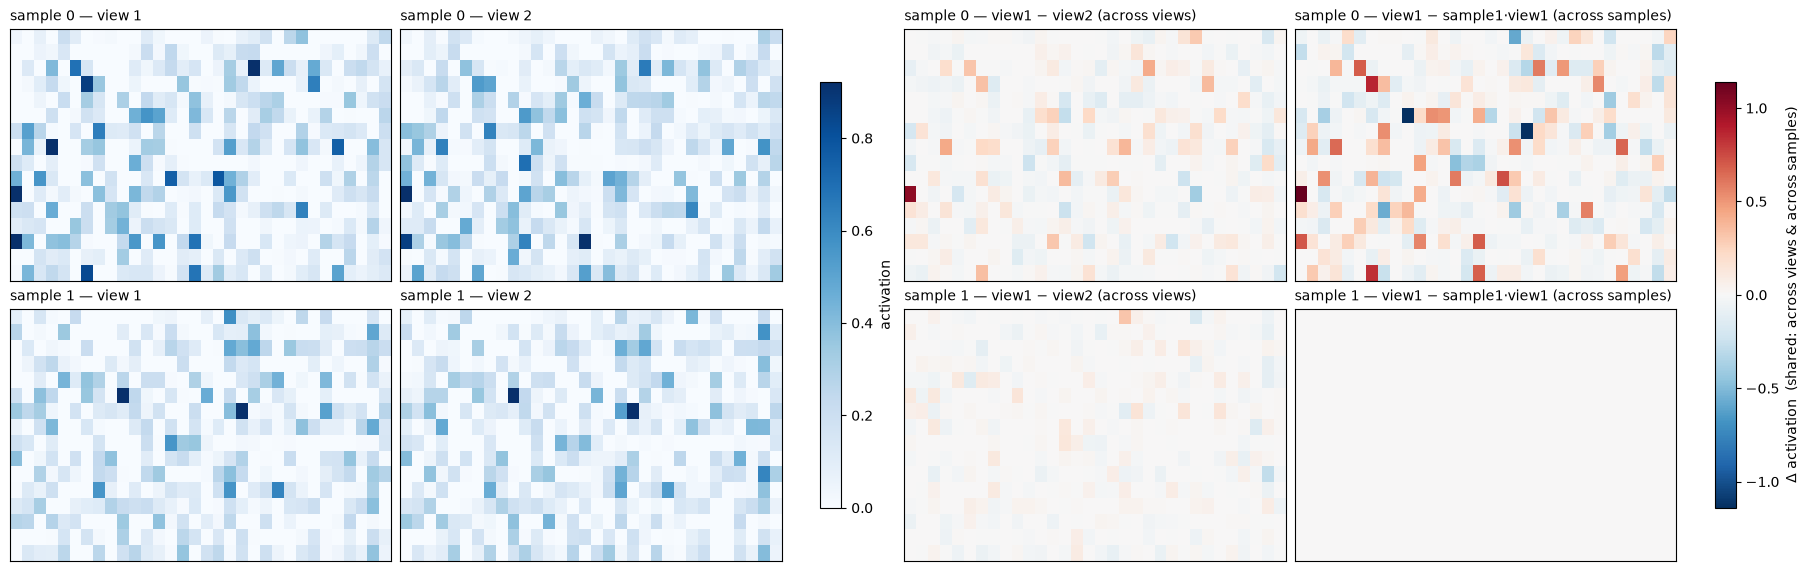

view 1: 32.5% zero activations
view 2: 26.2% zero activations
shared diff ceiling: 1.1399
mean |Δ| across views:   0.0357  (same image, two augmentations)
mean |Δ| across samples: 0.1038  (different images — should be larger)


In [14]:
import numpy as np

def show_feature_heatmaps(features_1, features_2, grid=(16, 32), vmax=None, diffmax=None):
    """Heatmap gallery of neuron activations for exactly TWO samples, one row each.

    Columns per sample:
      1. view 1 activations              (Blues)
      2. view 2 activations              (Blues)
      3. view 1 − view 2                 (RdBu)  -> across-VIEW  (same sample)
      4. view 1 − sample1's view 1       (RdBu)  -> across-SAMPLE (vs the 2nd sample)

    Columns 3 and 4 share ONE color scale (diffmax) so they are directly comparable:
    the same red means the same magnitude in both, so you can see that the across-sample
    difference (col 4) is much larger than the across-view difference (col 3).
    vmax:    activation ceiling (p99).  diffmax: shared difference ceiling (p99).
    Both fall back to batch-local estimates if not given.
    """
    if features_1.shape[0] < 2:
        raise ValueError("need at least 2 samples in the batch")
    n = 2   # this version handles exactly two samples

    f1 = features_1[:n].numpy().reshape(n, *grid)
    f2 = features_2[:n].numpy().reshape(n, *grid)
    view_diff = f1 - f2       # across-view (same sample)
    samp_diff = f1 - f1[1]    # across-sample: vs sample 1's first view

    if vmax is None:
        vmax = max(f1.max(), f2.max())
    if diffmax is None:
        # one scale for both diff columns; use the larger so neither clips
        diffmax = max(np.abs(view_diff).max(), np.abs(samp_diff).max())

    fig, axes = plt.subplots(n, 4, figsize=(18, 2.8 * n), constrained_layout=True, squeeze=False)

    for row in range(n):
        for col, (f, title) in enumerate([(f1, "view 1"), (f2, "view 2")]):
            ax = axes[row][col]
            im = ax.imshow(f[row], cmap="Blues", vmin=0.0, vmax=vmax, aspect="auto")
            ax.set_title(f"sample {row} — {title}", fontsize=10, loc="left")
            ax.set_xticks([])
            ax.set_yticks([])

        ax_v = axes[row][2]
        im_d = ax_v.imshow(view_diff[row], cmap="RdBu_r", vmin=-diffmax, vmax=diffmax, aspect="auto")
        ax_v.set_title(f"sample {row} — view1 − view2 (across views)", fontsize=10, loc="left")
        ax_v.set_xticks([])
        ax_v.set_yticks([])

        ax_s = axes[row][3]
        im_d = ax_s.imshow(samp_diff[row], cmap="RdBu_r", vmin=-diffmax, vmax=diffmax, aspect="auto")
        ax_s.set_title(f"sample {row} — view1 − sample1·view1 (across samples)", fontsize=10, loc="left")
        ax_s.set_xticks([])
        ax_s.set_yticks([])

    cbar = fig.colorbar(im, ax=axes[:, :2], shrink=0.8)
    cbar.set_label("activation")
    # single colorbar shared by BOTH difference columns (same scale)
    cbar_d = fig.colorbar(im_d, ax=axes[:, 2:4], shrink=0.8)
    cbar_d.set_label("Δ activation  (shared: across views & across samples)")

    plt.show()

    # fraction of neurons that are "dead" (exactly zero after ReLU)
    print(f"view 1: {(f1 == 0).mean():.1%} zero activations")
    print(f"view 2: {(f2 == 0).mean():.1%} zero activations")
    print(f"shared diff ceiling: {diffmax:.4f}")
    print(f"mean |Δ| across views:   {np.abs(view_diff).mean():.4f}  (same image, two augmentations)")
    print(f"mean |Δ| across samples: {np.abs(f1[0] - f1[1]).mean():.4f}  (different images — should be larger)")

# falls back to batch-local scaling if the global-scan cell hasn't been run yet
show_feature_heatmaps(features_1, features_2,
                      vmax=globals().get("global_vmax"), diffmax=globals().get("global_diffmax"))

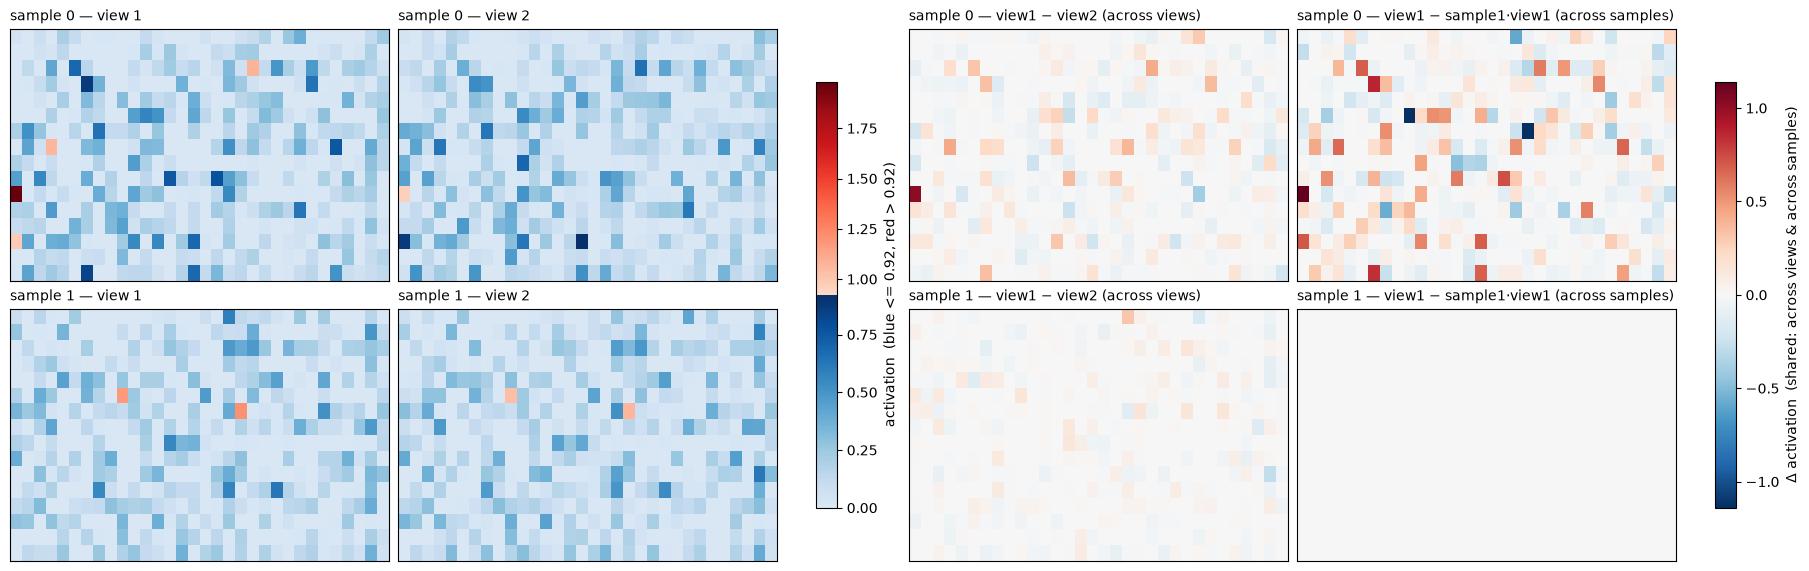

view 1: 32.5% zero activations
view 2: 26.2% zero activations
activation breakpoint = 0.922, max = 1.980, shared diff ceiling = 1.140
mean |Δ| across views:   0.0357
mean |Δ| across samples: 0.1038  (should be larger)


In [15]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def show_feature_heatmaps_segmented(features_1, features_2, grid=(16, 32), vmax=None, diffmax=None):
    """Same layout as show_feature_heatmaps (2 samples), but the view-1/view-2 activation
    panels use OPTION 2 — a segmented two-hue scale: blue up to the p99 breakpoint, red
    beyond it, so outlier neurons render as red instead of saturating.

    Difference columns 3 and 4 share ONE diverging scale (diffmax) so they are directly
    comparable — the same red means the same magnitude in the across-view and the
    across-sample panels.
    vmax: the blue->red breakpoint (p99).  diffmax: shared difference ceiling (p99).
    Both fall back to batch-local estimates if not given.
    """
    if features_1.shape[0] < 2:
        raise ValueError("need at least 2 samples in the batch")
    n = 2   # this version handles exactly two samples

    f1 = features_1[:n].numpy().reshape(n, *grid)
    f2 = features_2[:n].numpy().reshape(n, *grid)
    view_diff = f1 - f2       # across-view (same sample)
    samp_diff = f1 - f1[1]    # across-sample: vs sample 1's first view

    if vmax is None:
        vmax = float(np.quantile(np.concatenate([f1.ravel(), f2.ravel()]), 0.99))
    if diffmax is None:
        # one scale for both diff columns; use the larger so neither clips
        diffmax = max(np.abs(view_diff).max(), np.abs(samp_diff).max())

    # option 2: blue bulk (<= breakpoint) then red tail (> breakpoint)
    blues = plt.cm.Blues(np.linspace(0.15, 1.0, 128))
    reds = plt.cm.Reds(np.linspace(0.15, 1.0, 128))
    seg_cmap = LinearSegmentedColormap.from_list("blue_then_red", np.vstack([blues, reds]))
    act_hi = max(f1.max(), f2.max(), vmax * 1.001)          # true ceiling, guarded > breakpoint
    seg_norm = TwoSlopeNorm(vmin=0.0, vcenter=vmax, vmax=act_hi)

    fig, axes = plt.subplots(n, 4, figsize=(18, 2.8 * n), constrained_layout=True, squeeze=False)

    for row in range(n):
        for col, (f, title) in enumerate([(f1, "view 1"), (f2, "view 2")]):
            ax = axes[row][col]
            im = ax.imshow(f[row], cmap=seg_cmap, norm=seg_norm, aspect="auto")
            ax.set_title(f"sample {row} — {title}", fontsize=10, loc="left")
            ax.set_xticks([])
            ax.set_yticks([])

        ax_v = axes[row][2]
        im_d = ax_v.imshow(view_diff[row], cmap="RdBu_r", vmin=-diffmax, vmax=diffmax, aspect="auto")
        ax_v.set_title(f"sample {row} — view1 − view2 (across views)", fontsize=10, loc="left")
        ax_v.set_xticks([])
        ax_v.set_yticks([])

        ax_s = axes[row][3]
        im_d = ax_s.imshow(samp_diff[row], cmap="RdBu_r", vmin=-diffmax, vmax=diffmax, aspect="auto")
        ax_s.set_title(f"sample {row} — view1 − sample1·view1 (across samples)", fontsize=10, loc="left")
        ax_s.set_xticks([])
        ax_s.set_yticks([])

    cbar = fig.colorbar(im, ax=axes[:, :2], shrink=0.8)
    cbar.set_label(f"activation  (blue <= {vmax:.2f}, red > {vmax:.2f})")
    # single colorbar shared by BOTH difference columns (same scale)
    cbar_d = fig.colorbar(im_d, ax=axes[:, 2:4], shrink=0.8)
    cbar_d.set_label("Δ activation  (shared: across views & across samples)")

    plt.show()

    # fraction of neurons that are "dead" (exactly zero after ReLU)
    print(f"view 1: {(f1 == 0).mean():.1%} zero activations")
    print(f"view 2: {(f2 == 0).mean():.1%} zero activations")
    print(f"activation breakpoint = {vmax:.3f}, max = {act_hi:.3f}, shared diff ceiling = {diffmax:.3f}")
    print(f"mean |Δ| across views:   {np.abs(view_diff).mean():.4f}")
    print(f"mean |Δ| across samples: {np.abs(f1[0] - f1[1]).mean():.4f}  (should be larger)")

# falls back to batch-local scaling if the global-scan cell hasn't been run yet
show_feature_heatmaps_segmented(features_1, features_2,
                                vmax=globals().get("global_vmax"), diffmax=globals().get("global_diffmax"))

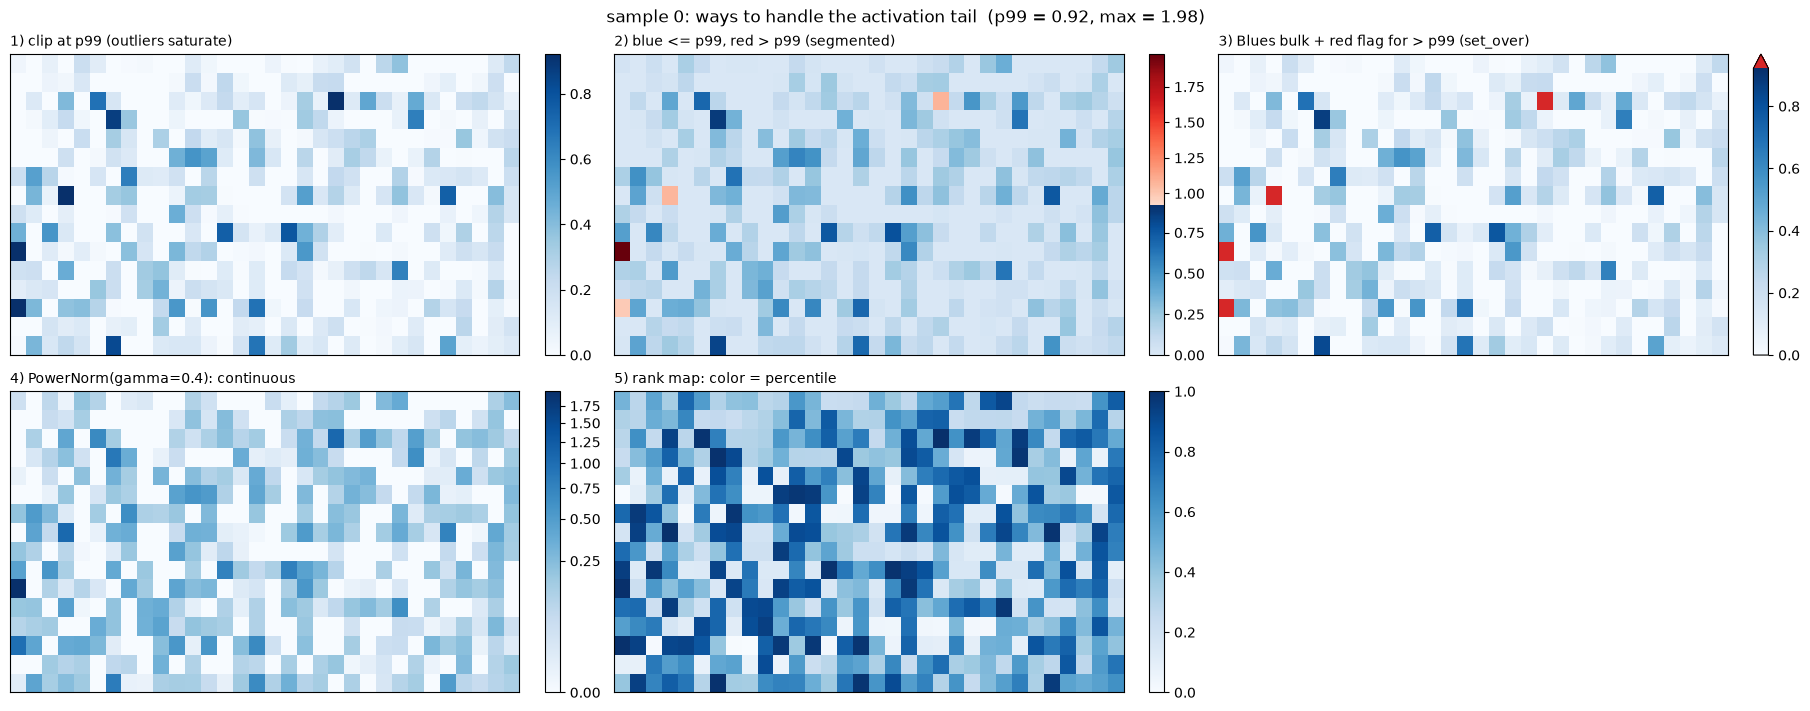

In [16]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, PowerNorm

# --- experiment: alternative ways to handle the heavy activation tail in one heatmap ---
idx = 0                              # which sample (first view) to visualize
bulk_q = 0.99                        # the "bulk vs outlier" breakpoint quantile
f = features_1[idx].numpy().reshape(16, 32)

p_hi = globals().get("global_vmax") or float(np.quantile(f, bulk_q))   # bulk ceiling
hi = max(f.max(), p_hi * 1.001)                                        # true max (guarded)

fig, axes = plt.subplots(2, 3, figsize=(18, 7), constrained_layout=True)

# 1) clip at p99 -- current approach; outliers all saturate to the darkest blue
im = axes[0, 0].imshow(f, cmap="Blues", vmin=0, vmax=p_hi, aspect="auto")
axes[0, 0].set_title("1) clip at p99 (outliers saturate)", fontsize=10, loc="left")
fig.colorbar(im, ax=axes[0, 0])

# 2) YOUR idea: segmented two-hue -- blue up to p99, red beyond (TwoSlopeNorm)
blues = plt.cm.Blues(np.linspace(0.15, 1.0, 128))
reds = plt.cm.Reds(np.linspace(0.15, 1.0, 128))
seg_cmap = LinearSegmentedColormap.from_list("blue_then_red", np.vstack([blues, reds]))
im = axes[0, 1].imshow(f, cmap=seg_cmap, norm=TwoSlopeNorm(vmin=0, vcenter=p_hi, vmax=hi), aspect="auto")
axes[0, 1].set_title("2) blue <= p99, red > p99 (segmented)", fontsize=10, loc="left")
fig.colorbar(im, ax=axes[0, 1])

# 3) set_over: bulk in one hue, tail flagged with a single highlight color
cmap_over = plt.cm.Blues.copy()
cmap_over.set_over("#d62728")
im = axes[0, 2].imshow(f, cmap=cmap_over, vmin=0, vmax=p_hi, aspect="auto")
axes[0, 2].set_title("3) Blues bulk + red flag for > p99 (set_over)", fontsize=10, loc="left")
fig.colorbar(im, ax=axes[0, 2], extend="max")

# 4) PowerNorm: one continuous hue, tail compressed (fits the ~exponential shape)
im = axes[1, 0].imshow(f, cmap="Blues", norm=PowerNorm(gamma=0.4, vmin=0, vmax=hi), aspect="auto")
axes[1, 0].set_title("4) PowerNorm(gamma=0.4): continuous", fontsize=10, loc="left")
fig.colorbar(im, ax=axes[1, 0])

# 5) rank map: color = within-sample percentile; uniform contrast for any distribution
ranks = np.argsort(np.argsort(f.flatten())) / (f.size - 1)
im = axes[1, 1].imshow(ranks.reshape(f.shape), cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[1, 1].set_title("5) rank map: color = percentile", fontsize=10, loc="left")
fig.colorbar(im, ax=axes[1, 1])

axes[1, 2].axis("off")   # spare panel

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f"sample {idx}: ways to handle the activation tail  (p99 = {p_hi:.2f}, max = {hi:.2f})", fontsize=12)
plt.show()

we summarize each class by one representative point: the mean (also called the centroid or prototype). Averaging over all 5000 frog images cancels out the per-image accidents — this frog's pose, that frog's background, lighting — and keeps what's common to frogs: the feature dimensions that consistently light up for the class. What survives the averaging is "frog-ness."

In [17]:
import numpy as np
from dataset import get_val_transforms

# ---- per-class representation: ORIGINAL images (no views/augmentation) -> encoder ----
# For each class we average the 512-d backbone features over all its images to get a
# single "class prototype" vector, then compare prototypes against each other.
CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]   # CIFAR-10 label order
n_classes, feat_dim = 10, 512

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")

# val transform = ToTensor + Normalize only  (the original image, not an augmented view)
class_ds = CIFAR10(root="./data", train=True, download=False, transform=get_val_transforms())
class_loader = DataLoader(class_ds, batch_size=256, shuffle=False, num_workers=2)

sums = torch.zeros(n_classes, feat_dim)
counts = torch.zeros(n_classes)

model.eval()
model.to(device)
with torch.no_grad():
    for x, y in class_loader:
        feats, _ = model(x.to(device))          # [B, 512] backbone features
        feats = feats.cpu()
        for c in range(n_classes):
            m = (y == c)
            if m.any():
                sums[c] += feats[m].sum(0)
                counts[c] += m.sum()
model.to("cpu")

centroids = (sums / counts[:, None]).numpy()    # [10, 512] mean feature per class
print("images per class:", dict(zip(CLASSES, counts.int().tolist())))
print("centroid matrix:", centroids.shape)

device: mps
images per class: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}
centroid matrix: (10, 512)


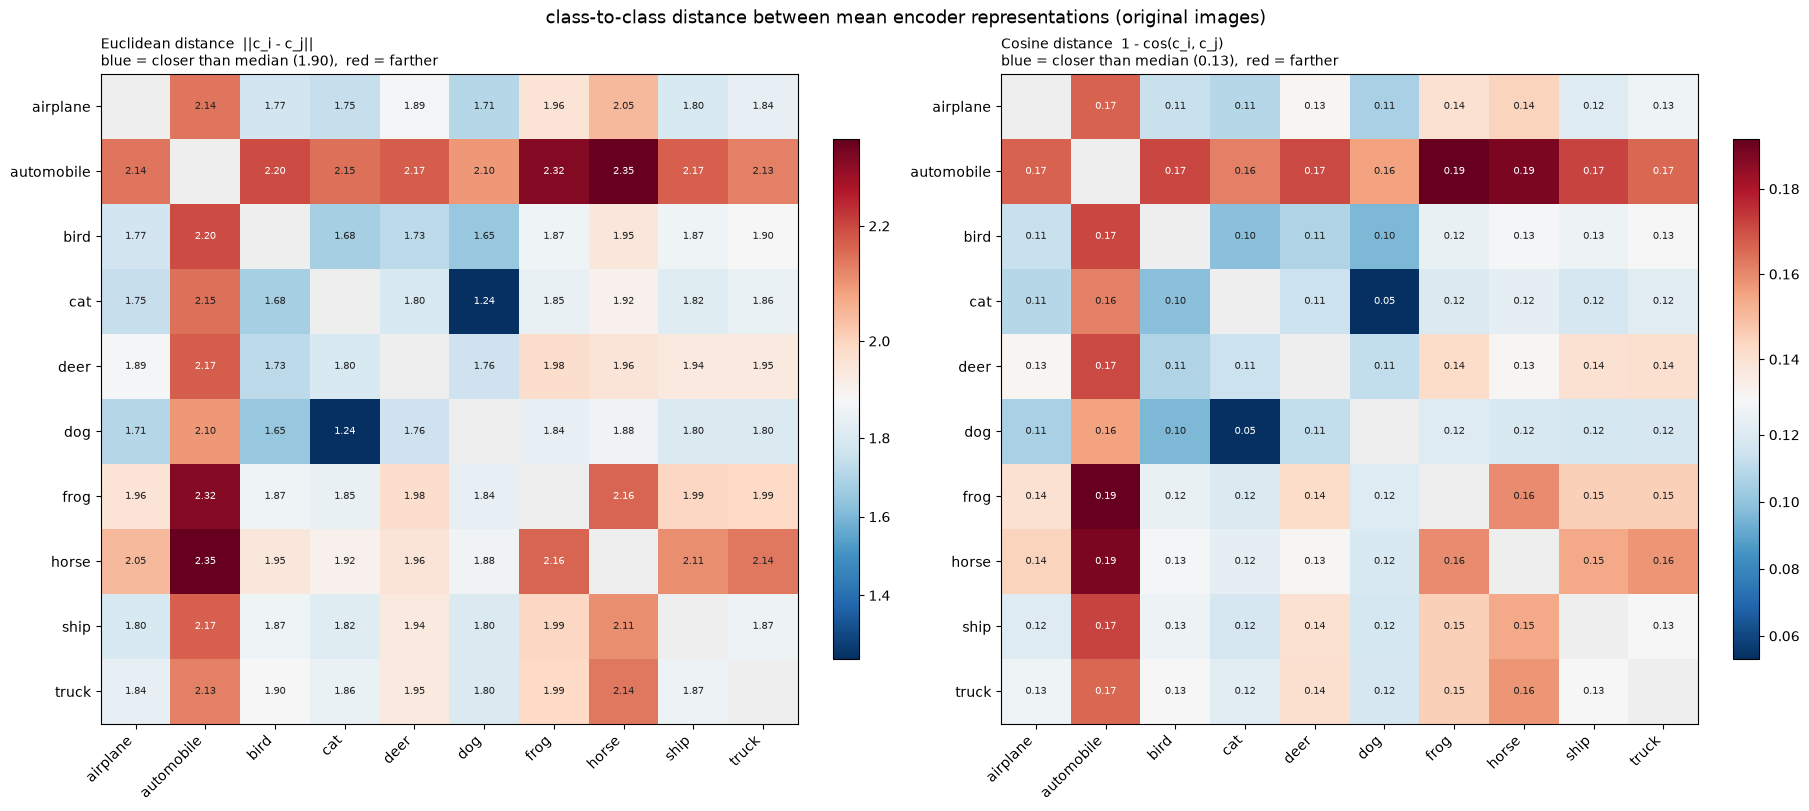


--- Euclidean ---
d(frog, horse)       = 2.164
d(frog, car)         = 2.316
  frog closer to horse than to car?  True   (gap +0.152)
d(frog, horse)       = 2.164   vs   d(car, boat) = 2.170   (|diff| 0.006)

--- Cosine ---
d(frog, horse)       = 0.159
d(frog, car)         = 0.192
  frog closer to horse than to car?  True   (gap +0.032)
d(frog, horse)       = 0.159   vs   d(car, boat) = 0.172   (|diff| 0.012)


In [18]:
from matplotlib.colors import TwoSlopeNorm

# ---- class-to-class distance between the mean representations ----
# euclidean: magnitude of the raw difference vector between two class prototypes
euc = np.linalg.norm(centroids[:, None] - centroids[None, :], axis=-1)   # [10, 10]
# cosine distance: 1 - cos(angle); ignores overall magnitude, compares direction only
unit = centroids / (np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-8)
cos = 1.0 - unit @ unit.T

fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

for ax, D, title in [(axes[0], euc, "Euclidean distance  ||c_i - c_j||"),
                     (axes[1], cos, "Cosine distance  1 - cos(c_i, c_j)")]:
    Dm = D.copy()
    np.fill_diagonal(Dm, np.nan)                        # drop self-distances from the scale
    off = Dm[~np.isnan(Dm)]
    vmin, vmid, vmax = off.min(), float(np.median(off)), off.max()
    vmid = min(max(vmid, vmin + 1e-9), vmax - 1e-9)     # keep strictly between for TwoSlopeNorm
    # diverging scale centered on the TYPICAL distance -> full contrast on both sides
    norm = TwoSlopeNorm(vmin=vmin, vcenter=vmid, vmax=vmax)

    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad("#eeeeee")                             # diagonal (NaN) shown as light gray
    im = ax.imshow(Dm, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(range(n_classes)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(n_classes)); ax.set_yticklabels(CLASSES)
    ax.set_title(f"{title}\nblue = closer than median ({vmid:.2f}),  red = farther", fontsize=10, loc="left")
    for i in range(n_classes):
        for j in range(n_classes):
            if i == j:
                continue
            t = float(norm(D[i, j]))                    # 0..1 position on the color scale
            ax.text(j, i, f"{D[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if (t < 0.22 or t > 0.78) else "#222222")
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle("class-to-class distance between mean encoder representations (original images)", fontsize=13)
plt.show()

# ---- the specific comparisons you asked about ----
def dist(a, b, D):
    return D[CLASSES.index(a), CLASSES.index(b)]

for name, D in [("Euclidean", euc), ("Cosine", cos)]:
    fh = dist("frog", "horse", D)
    fc = dist("frog", "automobile", D)   # "car"
    cs = dist("automobile", "ship", D)   # "car" vs "boat"
    print(f"\n--- {name} ---")
    print(f"d(frog, horse)       = {fh:.3f}")
    print(f"d(frog, car)         = {fc:.3f}")
    print(f"  frog closer to horse than to car?  {fh < fc}   (gap {fc - fh:+.3f})")
    print(f"d(frog, horse)       = {fh:.3f}   vs   d(car, boat) = {cs:.3f}   (|diff| {abs(fh - cs):.3f})")